In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import expm_multiply, expm
from scipy.sparse import diags
from utils import *
from qiskit.quantum_info import SparsePauliOp, Operator
from qiskit import QuantumCircuit

In [35]:
sorted(np.concatenate([2 * np.cos(np.arange(1, n//2+1) * np.pi / (n//2+1)), -2 * np.cos(np.arange(1, n//2+1) * np.pi / (n//2+1))]))

[-1.6180339887498951,
 -1.618033988749895,
 -0.618033988749895,
 -0.6180339887498948,
 0.6180339887498948,
 0.618033988749895,
 1.618033988749895,
 1.6180339887498951]

In [34]:
np.cos(np.arange(1, n//2) * np.pi / (n//2+1))

array([ 0.80901699,  0.30901699, -0.30901699])

In [33]:
[2 * np.cos(np.arange(1, n//2) * np.pi / (n//2+1)), -2 * np.cos(np.arange(1, n//2) * np.pi / (n//2+1))]

[array([ 1.61803399,  0.61803399, -0.61803399]),
 array([-1.61803399, -0.61803399,  0.61803399])]

In [31]:
sorted(evals.imag)

[-1.6180339887498956,
 -1.6180339887498956,
 -0.6180339887498947,
 -0.6180339887498947,
 0.6180339887498947,
 0.6180339887498947,
 1.6180339887498956,
 1.6180339887498956]

In [148]:
n = 100

A = np.zeros((n,n))
B = np.zeros((n,n))

for i in np.arange(0, n-1, 2):
    A[i,i+1] = 2 * np.random.rand()
    # A[i+1,i] = 1
for i in np.arange(1, n-1, 2):
    B[i,i+1] = 2 * np.random.rand()
    # B[i+1,i] = 1
A = (A + A.T) / 2
B = (B + B.T) / 2

print(A @ B - B @ A)
evals, evecs = np.linalg.eig(A @ B - B @ A)
print(np.max(np.abs((evals))))
# plt.plot(sorted(evals.imag))
# plt.plot(sorted(np.concatenate([2 * np.cos(np.arange(1, n//2+1) * np.pi / (n//2+1)), -2 * np.cos(np.arange(1, n//2+1) * np.pi / (n//2+1))])))

[[ 0.          0.          0.31042188 ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [-0.31042188  0.          0.         ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ...  0.          0.
  -0.11115613]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.11115613  0.
   0.        ]]
1.0137863622208942


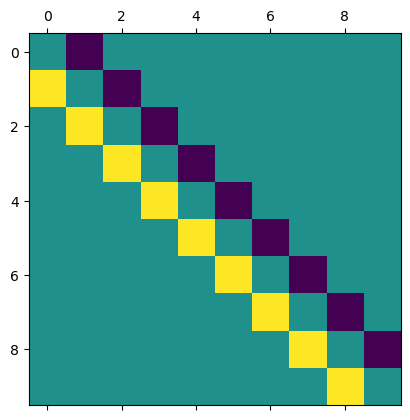

In [17]:
n = 10
A = np.zeros((n,n))
for i in range(n-1):
    A[i,i+1] = 1
    A[i+1,i] = 1

B = np.zeros((n,n), dtype=np.complex128)
for i in range(n):
    B[i,i] = np.exp(-1j * np.pi * i / 2)
C = np.conj(B) @ A @ B
plt.matshow(C.imag)
plt.show()

In [30]:
N = 6
dimension = 1
encoding = "unary"
n = num_qubits_per_dim(N, encoding)
codewords = get_codewords(N, dimension, encoding)
T = 5
num_time_points = 64
g = 1

In [32]:
J = np.zeros((n,n))
for i in range(n-1):
        J[i,i+1] = -1
h = np.zeros(n)
h[0] = 1
h[-1] = -1
H_pen = sum_J_zz(n, J) + sum_h_z(n, h)

In [62]:
H_sim = tensor([IDENTITY, PROJ_0, PAULI_X, PAULI_X, PAULI_X]) + tensor([PROJ_0, PAULI_X, PAULI_X, PAULI_X, PROJ_1]) + \
        tensor([PAULI_X, PAULI_X, PAULI_X, PROJ_1, IDENTITY])
H_sim += g * H_pen

psi_0 = np.zeros(2 ** n)
psi_0[codewords[0]] = 1

psi = expm_multiply(-1j * H_sim, psi_0, start=0, stop=T, num=num_time_points)
dist_ham_ebd = np.abs(psi[:,codewords]) ** 2

In [63]:
H_sim_2 = tensor([IDENTITY, PROJ_0, PAULI_X, PAULI_X, PAULI_X]) + tensor([PROJ_0, PAULI_X, PAULI_X, PAULI_X, PROJ_1]) + \
        tensor([PAULI_X, PAULI_X, PAULI_X, PROJ_1, IDENTITY])
H_sim_2 -= (tensor([IDENTITY, PROJ_0, PAULI_Y, PAULI_Y, PAULI_X]) + tensor([PROJ_0, PAULI_Y, PAULI_Y, PAULI_X, PROJ_1]) + \
        tensor([PAULI_Y, PAULI_Y, PAULI_X, PROJ_1, IDENTITY]))
# H_sim -= (tensor([IDENTITY, PROJ_0, PAULI_Y, PAULI_X, PAULI_Y]) + tensor([PROJ_0, PAULI_Y, PAULI_X, PAULI_Y, PROJ_1]) + \
#         tensor([PAULI_Y, PAULI_X, PAULI_Y, PROJ_1, IDENTITY]))
# H_sim -= (tensor([IDENTITY, PROJ_0, PAULI_X, PAULI_Y, PAULI_Y]) + tensor([PROJ_0, PAULI_X, PAULI_Y, PAULI_Y, PROJ_1]) + \
#         tensor([PAULI_X, PAULI_Y, PAULI_Y, PROJ_1, IDENTITY]))

H_sim_2 /= 2

H_sim_2 += g * H_pen

psi_0 = np.zeros(2 ** n)
psi_0[codewords[0]] = 1

psi = expm_multiply(-1j * H_sim_2, psi_0, start=0, stop=T, num=num_time_points)
dist_ham_ebd_2 = np.abs(psi[:,codewords]) ** 2

In [74]:
H_sim_3 = tensor([IDENTITY, PROJ_0, PAULI_X, PAULI_X, PAULI_X]) + tensor([PROJ_0, PAULI_X, PAULI_X, PAULI_X, PROJ_1]) + \
        tensor([PAULI_X, PAULI_X, PAULI_X, PROJ_1, IDENTITY])
H_sim_3 -= (tensor([IDENTITY, PROJ_0, PAULI_Y, PAULI_Y, PAULI_X]) + tensor([PROJ_0, PAULI_Y, PAULI_Y, PAULI_X, PROJ_1]) + \
        tensor([PAULI_Y, PAULI_Y, PAULI_X, PROJ_1, IDENTITY]))
H_sim_3 -= (tensor([IDENTITY, PROJ_0, PAULI_Y, PAULI_X, PAULI_Y]) + tensor([PROJ_0, PAULI_Y, PAULI_X, PAULI_Y, PROJ_1]) + \
        tensor([PAULI_Y, PAULI_X, PAULI_Y, PROJ_1, IDENTITY]))
H_sim_3 -= (tensor([IDENTITY, PROJ_0, PAULI_X, PAULI_Y, PAULI_Y]) + tensor([PROJ_0, PAULI_X, PAULI_Y, PAULI_Y, PROJ_1]) + \
        tensor([PAULI_X, PAULI_Y, PAULI_Y, PROJ_1, IDENTITY]))

H_sim_3 /= 4

H_sim_3 += g * H_pen

psi_0 = np.zeros(2 ** n)
psi_0[codewords[0]] = 1

psi = expm_multiply(-1j * H_sim_3, psi_0, start=0, stop=T, num=num_time_points)
dist_ham_ebd_3 = np.abs(psi[:,codewords]) ** 2

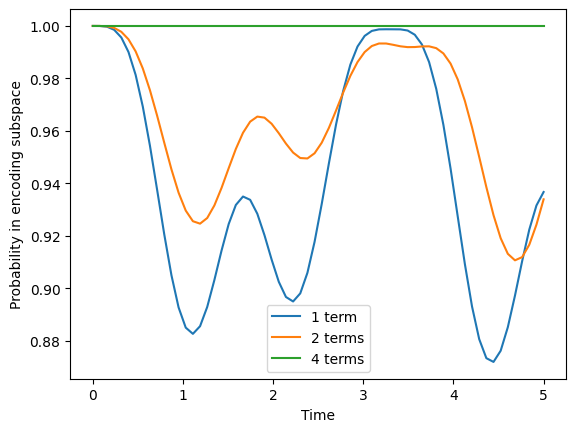

In [75]:
plt.plot(t_vals, np.sum(dist_ham_ebd, axis=1), label="1 term")
plt.plot(t_vals, np.sum(dist_ham_ebd_2, axis=1), label="2 terms")
plt.plot(t_vals, np.sum(dist_ham_ebd_3, axis=1), label="4 terms")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Probability in encoding subspace")
plt.show()

In [76]:
permutation = []
for i in range(N):
    permutation.append(codewords[i])
for i in range(2 ** N):
    if i not in permutation:
        permutation.append(i)

In [77]:
H_permuted = np.zeros((2 ** n, 2 ** n), dtype=np.complex64)
for i in range(2 ** n):
    for j in range(2 ** n):
        H_permuted[i,j] = H_sim_2.toarray()[permutation[i], permutation[j]]

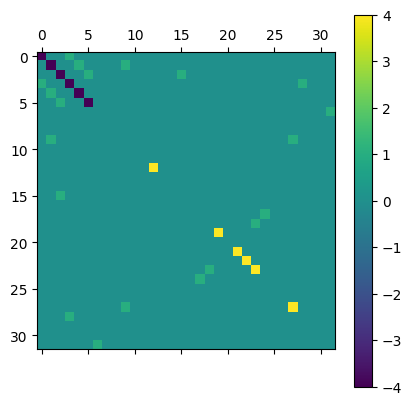

In [78]:
plt.matshow(H_permuted.real)
plt.colorbar()
plt.show()

Ground truth

In [79]:
psi_0 = np.zeros(N, dtype=np.complex128)
psi_0[0] = 1

H = diags([np.ones(N-3), np.ones(N-3)], offsets=[3,-3])

t_vals = np.linspace(0, T, num_time_points)
psi = expm_multiply(-1j * H, psi_0, start=0, stop=T, num=num_time_points)
dist_ideal = np.abs(psi) ** 2

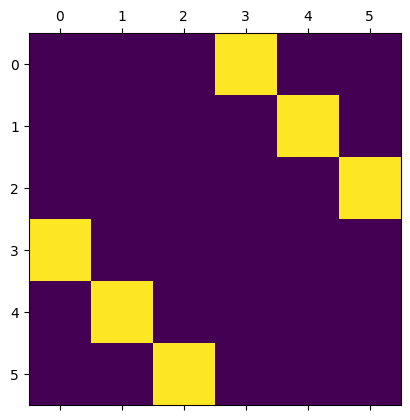

In [80]:
plt.matshow(H.toarray())
plt.show()

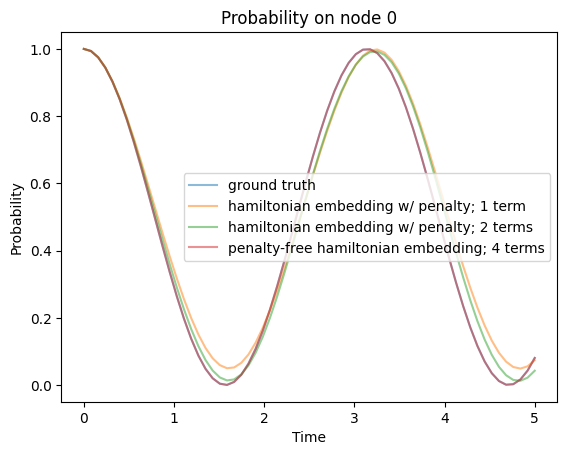

In [83]:
vertex = 0

plt.plot(t_vals, dist_ideal[:,vertex], label="ground truth", alpha=0.5)
plt.plot(t_vals, dist_ham_ebd[:,vertex], label="hamiltonian embedding w/ penalty; 1 term", alpha=0.5)
plt.plot(t_vals, dist_ham_ebd_2[:,vertex], label="hamiltonian embedding w/ penalty; 2 terms", alpha=0.5)
plt.plot(t_vals, dist_ham_ebd_3[:,vertex], label="penalty-free hamiltonian embedding; 4 terms", alpha=0.5)
plt.xlabel("Time")
plt.ylabel("Probability")
plt.title(f"Probability on node {vertex}")
plt.legend()
plt.show()